### Detect medicine from an image and identify the medicine name.

Flow:

Medicine Image
       |
       ↓
YOLOv8 Object Detection
       |
       ↓
Detected Medicine Name
       |
       ↓
Medicine Database / MCP Tool
       |
       ↓
Dosage + Purpose + Warning


### Install Required Packages
Create a new notebook:
           05_Medicine_Detection_YOLOv8.ipynb


In [7]:
!pip install ultralytics opencv-python pillow matplotlib
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 99.1 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 103.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.5/846.5 kB 52.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 MB 107.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 100.0 MB/s  0:00:040:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 106.2 MB/s  0:00:030:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 108.1 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 108.7 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 107.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 106.0 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.

### Import Libraries

In [8]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from PIL import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### Load YOLOv8 Model
For initial testing use pretrained YOLO:

In [9]:
model = YOLO("yolov8n.pt")

print("YOLOv8 Model Loaded")

YOLOv8 Model Loaded


### Upload Medicine Image

Example:
medicine.jpg

In [6]:
import os

os.listdir()

['medicine.yaml',
 'medicine_dataset',
 'runs',
 'yolov8n.pt',
 'Voice Assistant.ipynb',
 '.ipynb_checkpoints',
 '05: Medicine Detection using YOLOv8.ipynb']

In [8]:
import os

print(os.getcwd())

/notebooks/training_model


In [9]:
import os

print(os.path.exists("paracetamol.jpg"))

False


In [10]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if "paracetamol" in file.lower():
            print(os.path.join(root, file))

./medicine_dataset/images/val/paracetamol.jpg
./medicine_dataset/images/val/.ipynb_checkpoints/paracetamol-checkpoint.jpg
./medicine_dataset/images/train/paracetamol.jpg
./medicine_dataset/images/train/.ipynb_checkpoints/paracetamol-checkpoint.jpg
./medicine_dataset/labels/val/paracetamol.txt
./medicine_dataset/labels/train/paracetamol.txt
./medicine_dataset/labels/train/paracetamol1.txt
./medicine_dataset/labels/train/.ipynb_checkpoints/paracetamol-checkpoint.txt


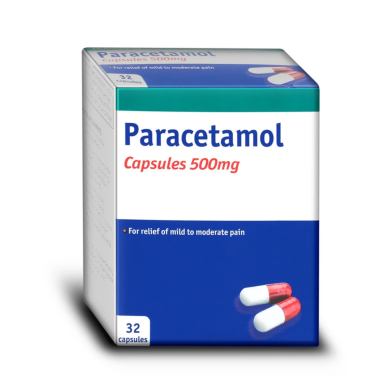

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "./medicine_dataset/images/train/paracetamol.jpg"

img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")
plt.show()

### Run Detection

In [12]:
results = model(image_path)

results


image 1/1 /notebooks/training_model/medicine_dataset/images/train/paracetamol.jpg: 640x640 (no detections), 49.1ms
Speed: 1.9ms preprocess, 49.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 

### Display Detection Result

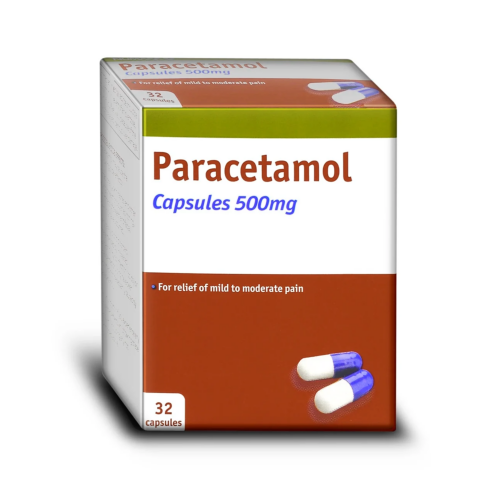

In [13]:
result_image = results[0].plot()

plt.figure(figsize=(8,6))
plt.imshow(result_image)
plt.axis("off")
plt.show()

### Extract Detected Objects

In [14]:
for result in results:

    boxes = result.boxes

    for box in boxes:

        class_id = int(box.cls)

        confidence = float(box.conf)

        label = model.names[class_id]

        print(
            "Object:",
            label,
            "Confidence:",
            confidence
        )

### Custom Medicine Detection

Because:
yolov8n.pt

is only a general object detection model.

It cannot detect:

Paracetamol
Metformin
Aspirin
Lisinopril

So we need:

Medicine Image
        |
        ↓
Custom YOLOv8 Model
        |
        ↓
Medicine Name
        |
        ↓
MCP Medicine Server
        |
        ↓
Dosage + Purpose + Warning

### Prepare Medicine Dataset

Collect medicine images
Create YOLO labels
Define classes
Example:

classes:
0 Paracetamol
1 Metformin
2 Aspirin
3 Lisinopril

### Create the YAML file using Python

In [15]:
yaml_content = """
path: /notebooks/ai-agents/medicine_dataset

train: images/train
val: images/val

names:
  0: paracetamol
  1: metformin
  2: aspirin
  3: lisinopril
"""

with open("medicine.yaml","w") as f:
    f.write(yaml_content)

print("updated")

updated


Verify YAML content:

In [16]:
with open("medicine.yaml", "r") as f:
    print(f.read())


path: /notebooks/ai-agents/medicine_dataset

train: images/train
val: images/val

names:
  0: paracetamol
  1: metformin
  2: aspirin
  3: lisinopril



### Create the dataset folders

In [17]:
import os

folders = [
    "medicine_dataset/images/train",
    "medicine_dataset/images/val",
    "medicine_dataset/labels/train",
    "medicine_dataset/labels/val"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Dataset folders created")

Dataset folders created


Check structure

In [18]:
import os

for root, dirs, files in os.walk("medicine_dataset"):
    print(root)

medicine_dataset
medicine_dataset/images
medicine_dataset/images/val
medicine_dataset/images/val/.ipynb_checkpoints
medicine_dataset/images/train
medicine_dataset/images/train/.ipynb_checkpoints
medicine_dataset/labels
medicine_dataset/labels/val
medicine_dataset/labels/train
medicine_dataset/labels/train/.ipynb_checkpoints
medicine_dataset/.ipynb_checkpoints


### Add YOLO labels

For every image, create a .txt file.

Example:

Image:
images/train/paracetamol1.jpg

Label:
labels/train/paracetamol1.txt

Content:
0 0.5 0.5 0.4 0.3

Meaning:
0 = paracetamol

In [19]:
import os

os.makedirs("medicine_dataset/labels/train", exist_ok=True)

with open("medicine_dataset/labels/train/paracetamol1.txt", "w") as f:
    f.write("0 0.5 0.5 0.4 0.3")

print("Label created")

Label created


### Train YOLOv8 Custom Model

In [24]:
import os

for root, dirs, files in os.walk("/notebooks"):
    if "paracetamol.jpg" in files:
        print(root)

/notebooks/training_model/medicine_dataset/images/val
/notebooks/training_model/medicine_dataset/images/train


In [4]:
import os

print(os.path.exists("/notebooks/training_model/medicine_dataset/data.yaml"))

True


In [2]:
!find /notebooks/training_model/medicine_dataset -name "*.txt"

/notebooks/training_model/medicine_dataset/labels/val/paracetamol.txt
/notebooks/training_model/medicine_dataset/labels/train/paracetamol.txt
/notebooks/training_model/medicine_dataset/labels/train/paracetamol1.txt
/notebooks/training_model/medicine_dataset/labels/train/asprininnn.txt
/notebooks/training_model/medicine_dataset/labels/train/.ipynb_checkpoints/paracetamol-checkpoint.txt
/notebooks/training_model/medicine_dataset/labels/train/.ipynb_checkpoints/asprininnn-checkpoint.txt


In [3]:
%%writefile /notebooks/training_model/medicine_dataset/data.yaml

train: /notebooks/training_model/medicine_dataset/images/train
val: /notebooks/training_model/medicine_dataset/images/val

nc: 2

names:
  0: paracetamol
  1: aspirin

Writing /notebooks/training_model/medicine_dataset/data.yaml


In [10]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="medicine_dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    name="medicine_detector"
)

Ultralytics 8.4.104 🚀 Python-3.12.3 torch-2.13.0+cu130 CPU (AMD Ryzen AI 9 HX 370 w/ Radeon 890M)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=medicine_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=medicine_detector-4, nbs=64, nms=False, ops

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x706923db2690>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

### Connect Detection with MCP Tool

Flow:

YOLO Detection
      |
      ↓
"paracetamol"
      |
      ↓
get_medication_info()
      |
      ↓
Medicine Details

extra commands

In [4]:
import os

print("Train images:")
print(os.listdir("medicine_dataset/images/train"))

print("\nValidation images:")
print(os.listdir("medicine_dataset/images/val"))

Train images:
['paracetamol.jpg', 'asprininnn.jpg', '.ipynb_checkpoints']

Validation images:
['paracetamol.jpg', '.ipynb_checkpoints']


In [5]:
print("Train labels:", os.listdir("medicine_dataset/labels/train"))
print("Validation labels:", os.listdir("medicine_dataset/labels/val"))


Train labels: ['paracetamol.txt', 'paracetamol1.txt', 'asprininnn.txt']
Validation labels: ['paracetamol.txt']


In [6]:
import shutil

shutil.copy(
    "medicine_dataset/images/train/paracetamol.jpg",
    "medicine_dataset/images/val/paracetamol.jpg"
)

print("Validation image created")

Validation image created


In [7]:
import os

print(os.listdir("medicine_dataset/images/val"))

['paracetamol.jpg', '.ipynb_checkpoints']


In [8]:
import os

os.makedirs("medicine_dataset/labels/train", exist_ok=True)
os.makedirs("medicine_dataset/labels/val", exist_ok=True)

# Label for paracetamol.jpg
with open("medicine_dataset/labels/train/paracetamol.txt", "w") as f:
    f.write("0 0.5 0.5 0.8 0.8")

# Label for asprininnn.jpg
with open("medicine_dataset/labels/train/asprininnn.txt", "w") as f:
    f.write("2 0.5 0.5 0.8 0.8")

print("Label files created.")

Label files created.


In [21]:
with open("medicine_dataset/labels/val/paracetamol.txt", "w") as f:
    f.write("0 0.5 0.5 0.8 0.8")